In [41]:
import rawpy
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image, ExifTags
import numpy as np


### Deliverable 3-5

In [70]:
imageFolder = Path("images")
imageFiles = sorted(imageFolder.glob("*.dng"))

imagePath = imageFiles[0]
print(f"Opening: {imagePath.resolve()}")
with rawpy.imread(str(imagePath)) as raw:
    print(f"Raw Type: {raw.raw_type}")
    print(f"Raw Shape: {raw.raw_image_visible.shape}")
    print(f"Raw Dtype: {raw.raw_image_visible.dtype}")
    print(f"Raw Pattern: {raw.raw_pattern}")
    print(f"Color Description: {raw.color_desc}")
    print(f"Black Level Per Channel: {raw.black_level_per_channel}")
    print(f"White Level: {raw.white_level}")
#     rgb = raw.postprocess(use_camera_wb=True)

# print(f"RGB shape: {rgb.shape}, dtype: {rgb.dtype}")
# plt.figure(figsize=(10, 8))
# plt.imshow(rgb)
# plt.axis("off")
# plt.show()

Opening: C:\Users\EMMWILL\repos\EE513\exercises\01_assignment\images\1F55F4EC-7F8E-4395-8CF9-C1CE2F7BA83D.dng
Raw Type: RawType.Flat
Raw Shape: (3024, 4032)
Raw Dtype: uint16
Raw Pattern: [[2 3]
 [1 0]]
Color Description: b'RGBG'
Black Level Per Channel: [528, 528, 528, 528]
White Level: 4095


### Deliverable 6-8

Opening: C:\Users\EMMWILL\repos\EE513\exercises\01_assignment\images\water2.dng
Raw Type: RawType.Flat
Raw Shape: (3024, 4032)
Raw Dtype: uint16
Raw Pattern: [[2 3]
 [1 0]]
Color Description: b'RGBG'
Black Level Per Channel: [528, 528, 528, 528]
White Level: 4095
Raw Colors: 3
RGB shape: (4032, 3024, 3), dtype: uint8


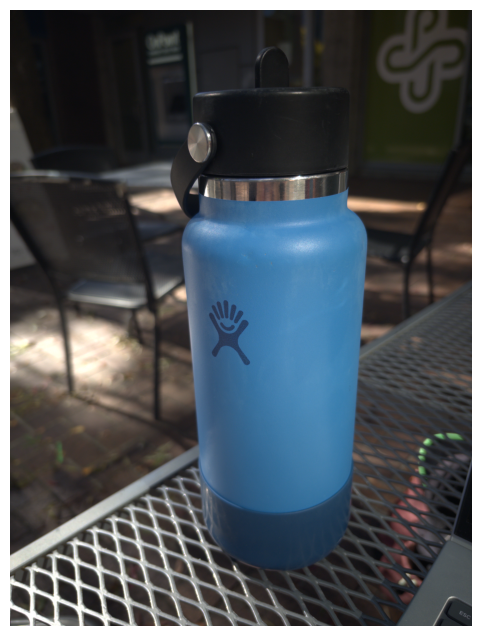

White Level: 4095
Hardware Bit Depth: 12-bit


In [71]:
imageFiles = sorted(imageFolder.glob("water2.dng"))

imagePath = imageFiles[0]
print(f"Opening: {imagePath.resolve()}")
with rawpy.imread(str(imagePath)) as raw:
    print(f"Raw Type: {raw.raw_type}")
    print(f"Raw Shape: {raw.raw_image_visible.shape}")
    print(f"Raw Dtype: {raw.raw_image_visible.dtype}")
    print(f"Raw Pattern: {raw.raw_pattern}")
    print(f"Color Description: {raw.color_desc}")
    print(f"Black Level Per Channel: {raw.black_level_per_channel}")
    print(f"White Level: {raw.white_level}")
    print(f"Raw Colors: {raw.num_colors}")
    rgb = raw.postprocess(use_camera_wb=True)

print(f"RGB shape: {rgb.shape}, dtype: {rgb.dtype}")
plt.figure(figsize=(10, 8))
plt.imshow(rgb)
plt.axis("off")
plt.show()
    
    
with rawpy.imread(str(imagePath)) as raw:
    # Get the sensor saturation value
    white_level = raw.white_level
    
    # Calculate the bit depth based on the white level
    bit_depth = white_level.bit_length()

print(f"White Level: {white_level}")
print(f"Hardware Bit Depth: {bit_depth}-bit")

In [48]:
imagePath = imageFolder / "water1.jpeg"

with Image.open(imagePath) as image:
    pixels = np.array(image)
    print(f"Format: {image.format}\n")
    print(f"Color Mode: {image.mode}\n")
    print(f"Shape: {pixels.shape}\n")
    print(f"Dtype: {pixels.dtype}")

Format: MPO

Color Mode: RGB

Shape: (4284, 5712, 3)

Dtype: uint8


In [73]:
imagePath = imageFolder / "water1.jpeg"
rotatedPath = imageFolder / "water1_rotated.png"

with Image.open(imagePath) as image:
    rotatedImage = image.convert("RGB").rotate(-90, expand=True)
    rotatedImage.save(rotatedPath)

print(f"Saved 90-degree clockwise rotation: {rotatedPath}")
print(f"Rotated dimensions: {rotatedImage.width}x{rotatedImage.height}")

Saved 90-degree clockwise rotation: images\water1_rotated.png
Rotated dimensions: 4284x5712


In [105]:
cropSize = 30
zoomFactor = 10
cropCoordinates = {
    "water1_rotated.png": (1842, 2540),  # (x, y) upper-left crop corner
    "water2.dng":(1398, 1895),
}

for imageName, (cropX, cropY) in cropCoordinates.items():
    imagePath = imageFolder / imageName

    if imagePath.suffix.lower() == ".dng":
        with rawpy.imread(str(imagePath)) as raw:
            pixels = raw.postprocess(use_camera_wb=True)
        image = Image.fromarray(pixels)
    else:
        with Image.open(imagePath) as sourceImage:
            image = sourceImage.convert("RGB")

    if (
        cropX < 0
        or cropY < 0
        or cropX + cropSize > image.width
        or cropY + cropSize > image.height
    ):
        raise ValueError(f"Crop at ({cropX}, {cropY}) does not fit in {imageName}")

    crop = image.crop((cropX, cropY, cropX + cropSize, cropY + cropSize))
    zoomed = crop.resize(
        (cropSize * zoomFactor, cropSize * zoomFactor),
        Image.Resampling.NEAREST,
    )

    outputPath = imageFolder / f"{imagePath.stem}_zoomed.png"
    zoomed.save(outputPath)
    print(
        f"Saved {cropSize}x{cropSize} crop at ({cropX}, {cropY}), "
        f"enlarged {zoomFactor}x: {outputPath}"
    )

Saved 30x30 crop at (1842, 2540), enlarged 10x: images\water1_rotated_zoomed.png
Saved 30x30 crop at (1398, 1895), enlarged 10x: images\water2_zoomed.png
